In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
!pip install catboost -q
from catboost import CatBoostRegressor
import joblib
import matplotlib.pyplot as plt

# 1. Load the feature-rich dataset
url = "https://github.com/shalomali/ed-arrival-forecasting/raw/main/data/processed/ed_model_ready.csv"

df = pd.read_csv(url, index_col='Datetime', parse_dates=True)

# 2. Chronological Train/Test Split
split_date = '2015-11-01'

train = df.loc[df.index < split_date]
test = df.loc[df.index >= split_date]

# 3. Separate Features (X) and Target (y)
# UPDATE: We are now dropping 'Date' alongside 'Arrivals' so XGBoost only sees numbers!
columns_to_drop = ['Arrivals', 'Date']

# We use errors='ignore' just in case the Date column was already dropped
X_train = train.drop(columns=columns_to_drop, errors='ignore')
y_train = train['Arrivals']

X_test = test.drop(columns=columns_to_drop, errors='ignore')
y_test = test['Arrivals']

print(f"Training Set: {len(X_train)} hours")
print(f"Testing Set: {len(X_test)} hours")

Training Set: 14772 hours
Testing Set: 1414 hours


In [4]:
X_train.head()

,Hour,DayOfWeek,Month,Is_Weekend,Lag_1h,Lag_2h,Lag_24h,Lag_168h,Rolling_Mean_3h_shifted,Rolling_Mean_12h_shifted,Rolling_Mean_24h_shifted
Datetime,,,,,,,,,,,
2014-01-08 00:00:00,0,2,1,0,3.0,4.0,1.0,2.0,3.666667,4.250000,3.500000
2014-01-08 01:00:00,1,2,1,0,4.0,3.0,1.0,2.0,2.666667,3.833333,3.500000
2014-01-08 02:00:00,2,2,1,0,1.0,4.0,2.0,3.0,2.000000,3.500000,3.458333
2014-01-08 04:00:00,4,2,1,0,1.0,1.0,1.0,1.0,1.000000,3.333333,3.458333
2014-01-08 05:00:00,5,2,1,0,1.0,1.0,1.0,2.0,1.666667,2.833333,3.541667


In [6]:
# 1. Check exactly which columns the model is being fed
print("FEATURES THE MODEL SEES:")
for col in X_train.columns:
    print(f"- {col}")

# 2. Let's look at the actual math for the very first row
print("\n--- FIRST ROW VALUES (X_train) ---")
print(X_train.iloc[10]) # Looking at row 10 to ensure lags are populated

print(f"\nTARGET VALUE (y_train): {y_train.iloc[10]}")

FEATURES THE MODEL SEES:
- Hour
- DayOfWeek
- Month
- Is_Weekend
- Lag_1h
- Lag_2h
- Lag_24h
- Lag_168h
- Rolling_Mean_3h_shifted
- Rolling_Mean_12h_shifted
- Rolling_Mean_24h_shifted

--- FIRST ROW VALUES (X_train) ---
Hour                        11.000000
DayOfWeek                    2.000000
Month                        1.000000
Is_Weekend                   0.000000
Lag_1h                       4.000000
Lag_2h                       3.000000
Lag_24h                      4.000000
Lag_168h                     4.000000
Rolling_Mean_3h_shifted      4.000000
Rolling_Mean_12h_shifted     2.416667
Rolling_Mean_24h_shifted     3.208333
Name: 2014-01-08 11:00:00, dtype: float64

TARGET VALUE (y_train): 5.0


In [5]:
# --- MODEL 1: XGBoost ---
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# --- MODEL 2: CatBoost ---
print("Training CatBoost...")
# CatBoost is incredibly smart about categorical features if we tell it which ones they are
categorical_features = ['Hour', 'DayOfWeek', 'Month', 'Is_Weekend']

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0 # Hides the massive wall of text during training
)
cb_model.fit(X_train, y_train, cat_features=categorical_features)
cb_preds = cb_model.predict(X_test)

# --- EVALUATION ---
def evaluate_model(name, true_values, predictions):
    mae = mean_absolute_error(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    # MAPE (Mean Absolute Percentage Error) - careful of division by zero!
    mape = np.mean(np.abs((true_values - predictions) / np.maximum(true_values, 1))) * 100

    print(f"--- {name} Performance ---")
    print(f"MAE:  {mae:.2f} patients (Average mistake per hour)")
    print(f"RMSE: {rmse:.2f} patients (Penalizes larger mistakes)")
    print(f"MAPE: {mape:.2f}%\n")

evaluate_model("XGBoost", y_test, xgb_preds)
evaluate_model("CatBoost", y_test, cb_preds)

Training XGBoost...
Training CatBoost...
--- XGBoost Performance ---
MAE:  0.06 patients (Average mistake per hour)
RMSE: 0.15 patients (Penalizes larger mistakes)
MAPE: 1.15%

--- CatBoost Performance ---
MAE:  0.08 patients (Average mistake per hour)
RMSE: 0.13 patients (Penalizes larger mistakes)
MAPE: 1.83%



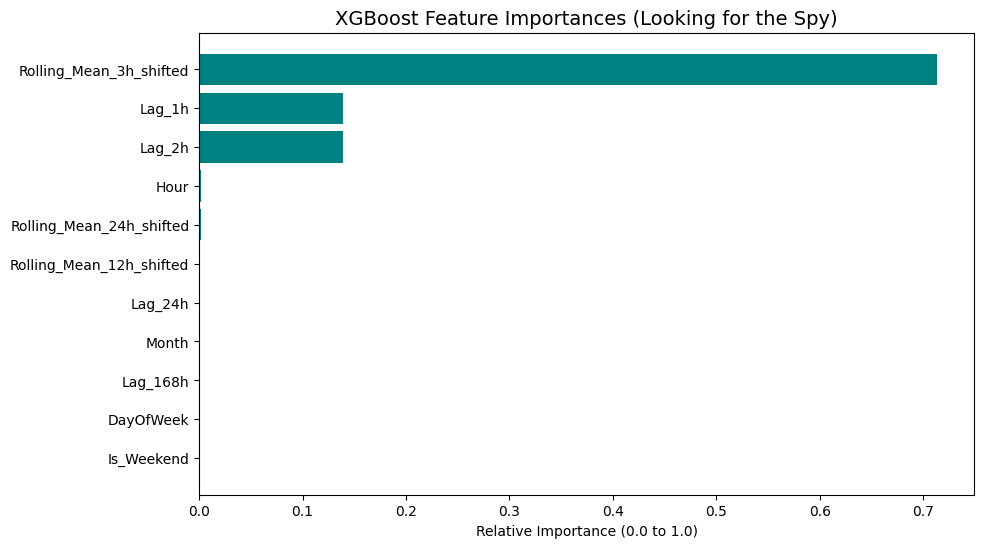

Datetime
2015-11-01 00:00:00     5.0
2015-11-01 01:00:00     5.0
2015-11-01 02:00:00     7.0
2015-11-01 03:00:00     2.0
2015-11-01 04:00:00     3.0
2015-11-01 05:00:00     4.0
2015-11-01 06:00:00     4.0
2015-11-01 07:00:00     3.0
2015-11-01 08:00:00     9.0
2015-11-01 09:00:00     5.0
2015-11-01 10:00:00     9.0
2015-11-01 11:00:00    11.0
2015-11-01 12:00:00     6.0
2015-11-01 13:00:00    10.0
2015-11-01 14:00:00     7.0
Name: Arrivals, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Ask XGBoost exactly which columns it relied on
importances = xgb_model.feature_importances_
features = X_train.columns

# Sort them from least to most important
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('XGBoost Feature Importances (Looking for the Spy)', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance (0.0 to 1.0)')
plt.show()

# Also, let's peek at the first 15 hours of the test set just to
# make sure the target variable isn't doing something bizarre.
print(y_test.head(15))